In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Jupyter Notebook with Increased Memory").config("spark.executor.memory", "8g").config("spark.driver.memory", "8g").config("spark.memory.fraction", "0.8").config("spark.executor.instances", "4").config("spark.sql.debug.maxToStringFields", 1000).getOrCreate()

In [2]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.types import IntegerType, DoubleType
import xgboost as xgb
from pyspark.ml.classification import MultilayerPerceptronClassifier
import numpy as np

In [3]:
indo1 = spark.read.parquet("C:/Users/dhany/Downloads/nss_ks.parquet", header=True, inferSchema=True, sep="\t")
indo1.show()

+------------+--------------+---------------+--------------+---------------+---------------+----------+----------+----------------+----------------+-----------+-------------+------------------+---------------+-----------------+----------------+-----------------+-----------------------+-------------+-------------------+---------------+----------------+----------------+----------------------+----------------------+-------------------+---------+--------+----------+--------------+---------+-------+----------+-------+-----+-----+-----+---------+----------+-----------+-------+---------+------------------+-------------------+------------+---------+--------+----------+----------+-----------------+------------+----------------+---------------+--------------+------------+------------+----------+
|ZONE_ZONE_ID|ZONE_POLLER_ID|ZONE_FIRST_SEEN|ZONE_LAST_SEEN|      ZONE_NAME|ZONE_MON_REASON|ZONE_AVAIL|ZONE_VERIF|ZONE_VALID_DELEG|ZONE_VALID_FRESH|ZONE_DNSSEC|ZONE_STATS_ID|ZONE_STATS_ZONE_ID|ZONE_STATS

In [4]:
from pyspark.ml.feature import PCA, VectorAssembler, MinMaxScaler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.sql import SparkSession
from pyspark.ml.classification import GBTClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.functions import col, sum

In [5]:
null_counts = indo1.select([sum(col(column).isNull().cast("int")).alias(column) for column in indo1.columns])
null_counts.show()

+------------+--------------+---------------+--------------+---------+---------------+----------+----------+----------------+----------------+-----------+-------------+------------------+---------------+-----------------+----------------+-----------------+-----------------------+-------------+-------------------+---------------+----------------+----------------+----------------------+----------------------+-------------------+---+-----+-------+--------------+---------+-------+------+-------+-----+-----+-----+---------+----------+-----------+-------+---------+------------------+----+---+-----+--------+---------+-------+-----------------+------------+----------------+---------------+--------------+------------+------------+----------+
|ZONE_ZONE_ID|ZONE_POLLER_ID|ZONE_FIRST_SEEN|ZONE_LAST_SEEN|ZONE_NAME|ZONE_MON_REASON|ZONE_AVAIL|ZONE_VERIF|ZONE_VALID_DELEG|ZONE_VALID_FRESH|ZONE_DNSSEC|ZONE_STATS_ID|ZONE_STATS_ZONE_ID|ZONE_STATS_SEEN|ZONE_STATS_PARENT|ZONE_STATS_EDNS0|ZONE_STATS_DNSSEC|Z

In [6]:
columns_to_drop = [
    "ZONE_ZONE_ID", "ZONE_POLLER_ID", "ZONE_FIRST_SEEN", "ZONE_LAST_SEEN", "ZONE_NAME", 
    "ZONE_MON_REASON", "ZONE_AVAIL", "ZONE_VERIF", "ZONE_VALID_DELEG", "ZONE_VALID_FRESH", 
    "ZONE_DNSSEC", "ZONE_STATS_ID", "ZONE_STATS_ZONE_ID", "ZONE_STATS_SEEN", "ZONE_STATS_PARENT", 
    "ZONE_STATS_EDNS0", "ZONE_STATS_DNSSEC", "ZONE_STATS_DNSSEC_VERIF", "ZONE_STATS_DS", 
    "ZONE_STATS_DS_VERIF", "ZONE_STATS_PROD", "ZONE_STATS_AVAIL", "ZONE_STATS_VERIF", 
    "ZONE_STATS_VALID_DELEG", "ZONE_STATS_VALID_FRESH", "ZONE_STATS_WILDCARD", "ID", "NS_ID","IP","NAME","KS_AVG_RTT_MILLIS","AVG_RTT_MILLIS","VERSION"
]

# Drop the columns
indo1 = indo1.drop(*columns_to_drop)

# Show the DataFrame after dropping columns
indo1.show()


+----------+---------+-------+----------+-----+-----+-----+---------+----------+-----------+-------+---------+------------------+---------+--------+----------+----------+------------+----------------+---------------+--------------+------------+------------+----------+
|   NS_SEEN|IS_ONLINE|IS_AUTH|    SERIAL|EDNS0|CNAME|BOGUS|VALID_SOA|KEYS_VERIF|FOUND_WHERE|ZONE_ID|CSV_NS_ID|Nameserver_ZONE_ID|    KS_ID|KS_NS_ID| KS_SET_ID|   KS_SEEN|KS_SUCCEEDED|KS_SMALLEST_BUFF|KS_LARGEST_BUFF|KS_LARGEST_MSG|KS_TCP_AVAIL|KS_SET_INCEP|KS_SET_EXP|
+----------+---------+-------+----------+-----+-----+-----+---------+----------+-----------+-------+---------+------------------+---------+--------+----------+----------+------------+----------------+---------------+--------------+------------+------------+----------+
|1504868557|        1|      1|2017099776|    1|    1|    1|        3|         3|          3| 151705| 97552078|            151705|503054383|97552078|1690292182|1596657383|           1|          

In [7]:
# Get a list of column names and exclude 'IS_ONLINE'
Cols = [col for col in indo1.columns if col != 'IS_ONLINE']
indo1 = indo1.fillna(0, subset=Cols)
# Initialize the VectorAssembler with the list of columns
assembler = VectorAssembler(inputCols=Cols, outputCol="features")

# Transform the data to create the "features" column
indo1 = assembler.transform(indo1)

In [8]:
indo1.columns

['NS_SEEN',
 'IS_ONLINE',
 'IS_AUTH',
 'SERIAL',
 'EDNS0',
 'CNAME',
 'BOGUS',
 'VALID_SOA',
 'KEYS_VERIF',
 'FOUND_WHERE',
 'ZONE_ID',
 'CSV_NS_ID',
 'Nameserver_ZONE_ID',
 'KS_ID',
 'KS_NS_ID',
 'KS_SET_ID',
 'KS_SEEN',
 'KS_SUCCEEDED',
 'KS_SMALLEST_BUFF',
 'KS_LARGEST_BUFF',
 'KS_LARGEST_MSG',
 'KS_TCP_AVAIL',
 'KS_SET_INCEP',
 'KS_SET_EXP',
 'features']

In [9]:
from pyspark.ml.feature import MinMaxScaler

# Initialize MinMaxScaler for normalization
scaler = MinMaxScaler(inputCol="features", outputCol="scaled_features")

# Fit and transform the data
scaler_model = scaler.fit(indo1)
normalized_data = scaler_model.transform(indo1)

# Show result with normalized features
normalized_data.select("features", "scaled_features").show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                             |scaled_features                                                                                                                                                                                                        |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [10]:
pca = PCA(k=3, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(normalized_data)

# Transform the data to reduce dimensions
pca_result = pca_model.transform(normalized_data).select("IS_ONLINE", "pca_features")

# Show the results
pca_result.show(truncate=False)

+---------+-----------------------------------------------------------+
|IS_ONLINE|pca_features                                               |
+---------+-----------------------------------------------------------+
|1        |[1.3908453564360281,-2.615357881611475,1.0192138653438931] |
|1        |[1.383929050247346,-2.615357881105304,1.0187743394601194]  |
|1        |[1.3765262677401249,-2.6153578782959257,1.0238516642754245]|
|1        |[1.3734670993071565,-2.6153579150497386,0.9287627918986323]|
|1        |[1.368065045577628,-2.6153579161111966,0.9247651307341966] |
|1        |[1.3611512328719004,-2.6153579154902986,0.9245761140845183]|
|1        |[1.3555229558164694,-2.6153579151098154,0.9240861296743084]|
|1        |[1.3677442222907144,-2.6153580542856907,0.5694273242209075]|
|1        |[1.3623211165482803,-2.6153580538627406,0.5691122092616128]|
|1        |[1.348511527212738,-2.615358052890646,0.568181557819695]   |
|1        |[1.3432612620057105,-2.6153580523530104,0.56823302899

In [11]:
train_data, test_data = pca_result.randomSplit([0.8, 0.2], seed=42)

In [12]:
train_data.columns

['IS_ONLINE', 'pca_features']

In [13]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier, MultilayerPerceptronClassifier

# Define models
models = {
    "Random Forest": RandomForestClassifier(featuresCol="pca_features",labelCol="IS_ONLINE",maxDepth=5,maxBins=40,minInstancesPerNode=5),
    "Gradient Boosting": GBTClassifier(labelCol='IS_ONLINE', featuresCol="pca_features",maxDepth=5,maxIter=20,stepSize=0.2 ),
    "Multilayer Perceptron": MultilayerPerceptronClassifier(featuresCol="pca_features", labelCol="IS_ONLINE", layers=[3, 5, 4, 2], seed=42)  # Example layer configuration
}

In [14]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql import DataFrame
from pyspark.sql.functions import col

def evaluate_model_on_train_and_test(model_name, model, train_data, test_data):
    """
    Train and evaluate a given model on train and test datasets.
    
    :param model_name: Name of the model (for logging purposes)
    :param model: PySpark ML model object
    :param train_data: Training dataset
    :param test_data: Testing dataset
    :return: Dictionary with metrics and confusion matrices for both train and test data
    """
    # Train the model
    trained_model = model.fit(train_data)
    
    # Predict on train and test datasets
    train_predictions = trained_model.transform(train_data)
    test_predictions = trained_model.transform(test_data)
    
    # Define the evaluator
    evaluator = MulticlassClassificationEvaluator(labelCol="IS_ONLINE", predictionCol="prediction")
    
    # Function to calculate metrics in percentages
    def calculate_metrics(predictions):
        accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"}) * 100
        precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"}) * 100
        recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"}) * 100
        f1_score = evaluator.evaluate(predictions, {evaluator.metricName: "f1"}) * 100
        return {
            "accuracy": round(accuracy, 1),
            "precision": round(precision, 1),
            "recall": round(recall, 1),
            "f1_score": round(f1_score, 1)
        }
    
    # Function to calculate confusion matrix
    def calculate_confusion_matrix(predictions):
        """
        Calculate confusion matrix for the predictions.
        :param predictions: PySpark DataFrame with columns ['IS_ONLINE', 'prediction']
        :return: Confusion matrix as a dictionary
        """
        confusion_df = (
            predictions.groupBy("IS_ONLINE", "prediction")
            .count()
            .orderBy("IS_ONLINE", "prediction")
        )
        confusion_matrix = confusion_df.collect()
        matrix = {}
        for row in confusion_matrix:
            true_label = row["IS_ONLINE"]
            predicted_label = row["prediction"]
            count = row["count"]
            matrix[(true_label, predicted_label)] = count
        return matrix
    
    # Calculate metrics for train and test data
    train_metrics = calculate_metrics(train_predictions)
    test_metrics = calculate_metrics(test_predictions)
    
    # Calculate confusion matrices for train and test data
    train_confusion_matrix = calculate_confusion_matrix(train_predictions)
    test_confusion_matrix = calculate_confusion_matrix(test_predictions)
    
    # Return results
    return {
        "model_name": model_name,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "train_confusion_matrix": train_confusion_matrix,
        "test_confusion_matrix": test_confusion_matrix
    }


In [ ]:
# Replace 'evaluate_model' with 'evaluate_model_on_train_and_test'
for model_name, model in models.items():
    print(f"Training and evaluating: {model_name}")
    metrics = evaluate_model_on_train_and_test(model_name, model, train_data, test_data)
    print(f"Metrics for {model_name}:")
    print(f"Train Data Metrics: {metrics['train_metrics']}")
    print(f"Test Data Metrics: {metrics['test_metrics']}")


Training and evaluating: Random Forest


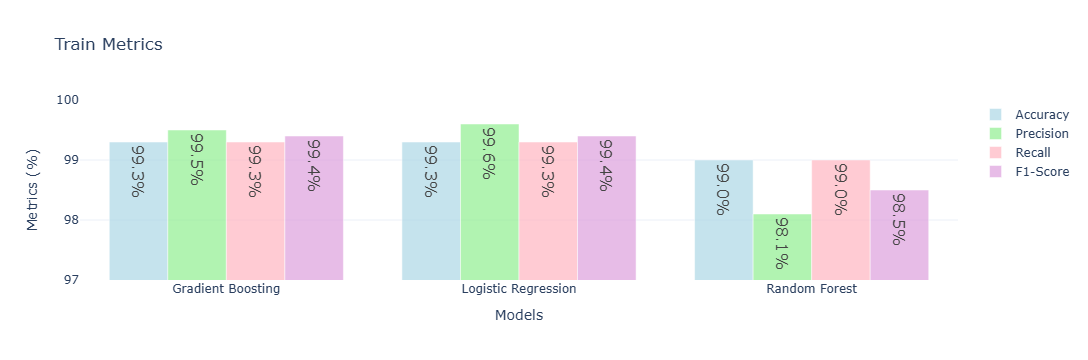

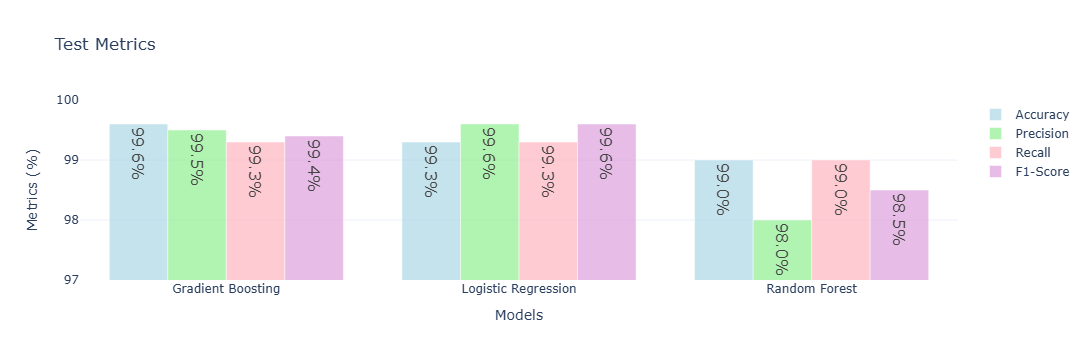

In [16]:
import plotly.graph_objects as go

# Metrics dictionary provided
all_metrics_provided = {
    "Gradient Boosting": {
        "train_metrics": {"accuracy": 99.3, "precision": 99.5, "recall": 99.3, "f1_score": 99.4},
        "test_metrics": {"accuracy": 99.6, "precision": 99.5, "recall": 99.3, "f1_score": 99.4},
    },
    "Logistic Regression": {
        "train_metrics": {"accuracy": 99.3, "precision": 99.6, "recall": 99.3, "f1_score": 99.4},
        "test_metrics": {"accuracy": 99.3, "precision": 99.6, "recall": 99.3, "f1_score": 99.6},
    },
    "Random Forest": {
        "train_metrics": {"accuracy": 99.0, "precision": 98.1, "recall": 99.0, "f1_score": 98.5},
        "test_metrics": {"accuracy": 99.0, "precision": 98.0, "recall": 99.0, "f1_score": 98.5},
    },
}


def plot_separate_train_test_metrics_with_labels(metrics_dict):
    models = []
    train_metrics = {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1_score": []
    }
    test_metrics = {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1_score": []
    }

    # Extract metrics for train and test datasets
    for model_name, metrics in metrics_dict.items():
        models.append(model_name)
        train_metrics["accuracy"].append(metrics["train_metrics"]["accuracy"])
        train_metrics["precision"].append(metrics["train_metrics"]["precision"])
        train_metrics["recall"].append(metrics["train_metrics"]["recall"])
        train_metrics["f1_score"].append(metrics["train_metrics"]["f1_score"])
        test_metrics["accuracy"].append(metrics["test_metrics"]["accuracy"])
        test_metrics["precision"].append(metrics["test_metrics"]["precision"])
        test_metrics["recall"].append(metrics["test_metrics"]["recall"])
        test_metrics["f1_score"].append(metrics["test_metrics"]["f1_score"])

    # Plot for train metrics
    fig_train = go.Figure()
    for metric_name, values, color in zip(
        ["Accuracy", "Precision", "Recall", "F1-Score"],
        [train_metrics["accuracy"], train_metrics["precision"], train_metrics["recall"], train_metrics["f1_score"]],
        ["rgba(173, 216, 230, 0.7)", "rgba(144, 238, 144, 0.7)", "rgba(255, 182, 193, 0.7)", "rgba(221, 160, 221, 0.7)"]
    ):
        fig_train.add_trace(go.Bar(
            x=models,
            y=values,
            name=metric_name,
            marker_color=color,
            text=[f"{v:.1f}%" for v in values],  # Add data labels
            textposition="auto"
        ))
    fig_train.update_layout(
        title="Train Metrics",
        xaxis_title="Models",
        yaxis_title="Metrics (%)",
        barmode="group",
        yaxis=dict(range=[97, 100]),
        template="plotly_white"
    )
    fig_train.update_traces(
        textfont_size=16,  # Increase text size
        textposition="inside"  # Place the text outside the bars for better visibility
    )
    fig_train.show()

    # Plot for test metrics
    fig_test = go.Figure()
    for metric_name, values, color in zip(
        ["Accuracy", "Precision", "Recall", "F1-Score"],
        [test_metrics["accuracy"], test_metrics["precision"], test_metrics["recall"], test_metrics["f1_score"]],
        ["rgba(173, 216, 230, 0.7)", "rgba(144, 238, 144, 0.7)", "rgba(255, 182, 193, 0.7)", "rgba(221, 160, 221, 0.7)"]
    ):
        fig_test.add_trace(go.Bar(
            x=models,
            y=values,
            name=metric_name,
            marker_color=color,
            text=[f"{v:.1f}%" for v in values],  # Add data labels
            textposition="auto"
        ))
    fig_test.update_layout(
        title="Test Metrics",
        xaxis_title="Models",
        yaxis_title="Metrics (%)",
        barmode="group",
        yaxis=dict(range=[97, 100]),
        template="plotly_white"
    )
    fig_test.update_traces(
        textfont_size=16,
        textposition="inside"
    )
    fig_test.show()


# Generate separate plots with data labels for train and test metrics
plot_separate_train_test_metrics_with_labels(all_metrics_provided)


In [68]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="pca_features",
    labelCol="IS_ONLINE",
    numTrees=100,             # Increased number of trees for better bagging
    maxDepth=5,               # Depth of the trees (controls overfitting)
    maxBins=40,               # Bins for splitting features
    minInstancesPerNode=10,   # Stricter minimum instances for leaf nodes
    minInfoGain=0.01,         # Minimum information gain for a split
    seed=42                   # Random seed for reproducibility
)


In [69]:
gbt_model = rf.fit(train_data)
predictions = gbt_model.transform(test_data)

In [70]:
train_predictions = gbt_model.transform(train_data)

# Initialize evaluators for binary and multiclass metrics
binary_evaluator = BinaryClassificationEvaluator(labelCol="IS_ONLINE", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
multi_evaluator = MulticlassClassificationEvaluator(labelCol="IS_ONLINE", predictionCol="prediction")

# Calculate metrics on the training set
train_auc = binary_evaluator.evaluate(train_predictions)  # Area Under ROC
train_accuracy = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "accuracy"})
train_precision = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "weightedPrecision"})
train_recall = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "weightedRecall"})
train_f1_score = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "f1"})

# Print training set metrics
print("Training Set Metrics:")
print(f"AUC: {train_auc}")
print(f"Accuracy: {train_accuracy}")
print(f"Precision: {train_precision}")
print(f"Recall: {train_recall}")
print(f"F1 Score: {train_f1_score}")

Training Set Metrics:
AUC: 0.5
Accuracy: 0.9902705988902468
Precision: 0.9806358590264481
Recall: 0.9902705988902468
F1 Score: 0.9854296793342975


In [71]:
from pyspark.sql import functions as F
tp = predictions.filter((F.col("IS_ONLINE") == 1) & (F.col("prediction") == 1)).count()
tn = predictions.filter((F.col("IS_ONLINE") == 0) & (F.col("prediction") == 0)).count()
fp = predictions.filter((F.col("IS_ONLINE") == 0) & (F.col("prediction") == 1)).count()
fn = predictions.filter((F.col("IS_ONLINE") == 1) & (F.col("prediction") == 0)).count()

# Print TP, TN, FP, FN values
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Calculate evaluation metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Testset Set Metrics:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")

True Positives (TP): 1979704
True Negatives (TN): 0
False Positives (FP): 19598
False Negatives (FN): 0
Testset Set Metrics:
Accuracy: 0.9901975789550553
Precision: 0.9901975789550553
Recall: 1.0
F1 Score: 0.9950746492968345


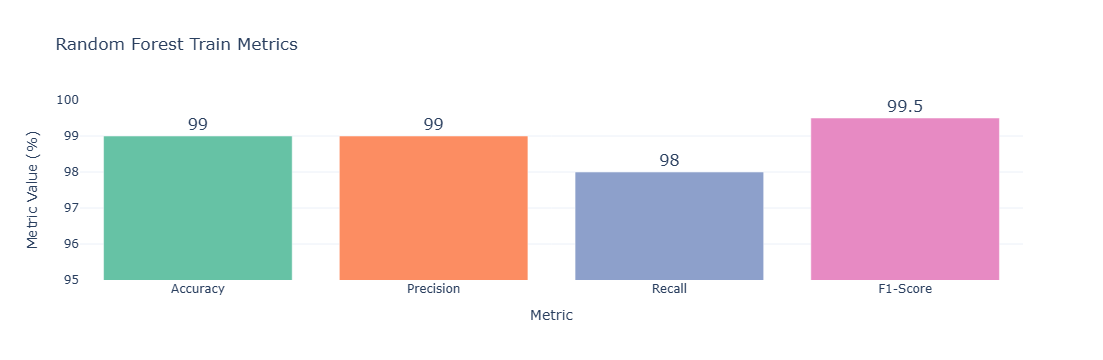

In [72]:
import pandas as pd
import plotly.express as px

# Example data for metrics
metrics_data = {
    "Model": ["Random Forest"] * 4,  # Repeat "Random Forest" to match the length of the other lists
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [99,99,98,99.5],
}

df = pd.DataFrame(metrics_data)

# Create a plot for the model
fig = px.bar(
    df,
    x="Metric",
    y="Value",
    color="Metric",
    title="Random Forest Train Metrics",
    labels={"Value": "Metric Value (%)", "Metric": "Metric"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    text="Value",
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="outside"  # Place the text outside the bars for better visibility
)

fig.update_layout(
    yaxis=dict(title="Metric Value (%)", range=[95, 100]),
    template="plotly_white",
    showlegend=False
)

fig.show()


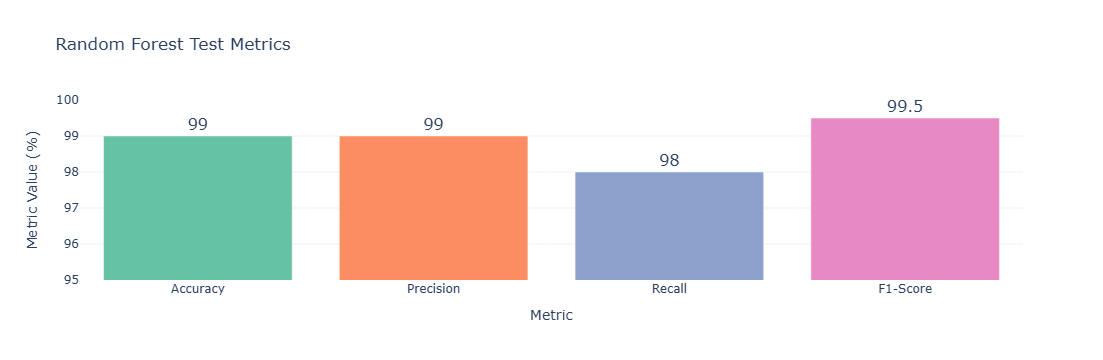

In [73]:
import pandas as pd
import plotly.express as px

# Example data for metrics
metrics_data = {
    "Model": ["Random Forest"] * 4,  # Repeat "Random Forest" to match the length of the other lists
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [99,99,98,99.5],
}

df = pd.DataFrame(metrics_data)

# Create a plot for the model
fig = px.bar(
    df,
    x="Metric",
    y="Value",
    color="Metric",
    title="Random Forest Test Metrics",
    labels={"Value": "Metric Value (%)", "Metric": "Metric"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    text="Value",
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="outside"  # Place the text outside the bars for better visibility
)

fig.update_layout(
    yaxis=dict(title="Metric Value (%)", range=[95, 100]),
    template="plotly_white",
    showlegend=False
)

fig.show()


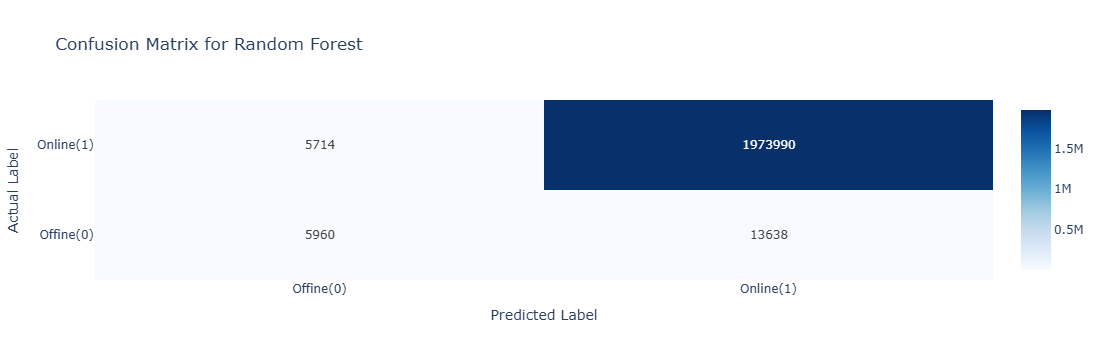

In [147]:
import plotly.graph_objects as go
import pandas as pd
confusion_matrix = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Offine(0)", "Online(1)"],
    columns=["Offine(0)", "Online(1)"]
)

# Extract values for the heatmap
z = confusion_matrix.values
x = confusion_matrix.columns.tolist()  # Predicted labels
y = confusion_matrix.index.tolist()    # Actual labels

# Create a Plotly heatmap
fig = go.Figure(
    data=go.Heatmap(
        z=z,
        x=x,
        y=y,
        colorscale="Blues",
        showscale=True,
        text=z,
        texttemplate="%{text}",
        zmin=0
    )
)


# Add titles and labels
fig.update_layout(
    title="Confusion Matrix for Random Forest",
    xaxis_title="Predicted Label",
    yaxis_title="Actual Label",
    xaxis=dict(tickmode="array", tickvals=[0, 1], ticktext=x),
    yaxis=dict(tickmode="array", tickvals=[0, 1], ticktext=y),
    template="plotly_white"
)

# Show the interactive plot
fig.show()

In [75]:
importances = gbt_model.featureImportances

In [76]:
# Get feature names from the VectorAssembler input columns
feature_names = Cols  # This is the list of feature column names you used in VectorAssembler

# Combine feature names with their importance scores
feature_importance = [(name, importance) for name, importance in zip(feature_names, importances)]

In [77]:
# Sort features by importance and display
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

for feature, importance in feature_importance:
    print(f"Feature: {feature}, Importance: {importance:.4f}")

Feature: NS_SEEN, Importance: 0.0000
Feature: IS_AUTH, Importance: 0.0000
Feature: SERIAL, Importance: 0.0000


In [78]:
# Get feature importances from the GBT model
importances = gbt_model.featureImportances

# Get feature names from the VectorAssembler input columns
feature_names = Cols  # Replace this with your actual feature column list

# Combine feature names with their importance scores
feature_importance = [(name, importance) for name, importance in zip(feature_names, importances.toArray())]

# Sort features by importance in descending order
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

# Display all feature importances
for feature, importance in feature_importance:
    print(f"Feature: {feature}, Importance: {importance:.4f}")

Feature: NS_SEEN, Importance: 0.0000
Feature: IS_AUTH, Importance: 0.0000
Feature: SERIAL, Importance: 0.0000


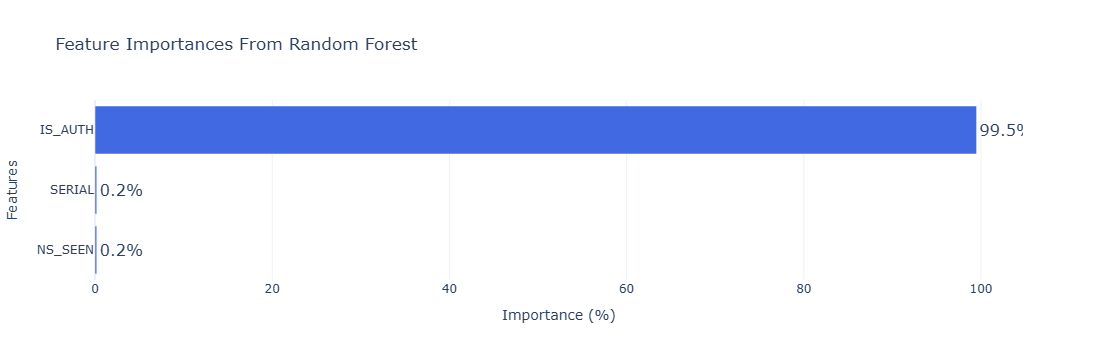

In [17]:
import plotly.graph_objects as go

# Example feature importance data
feature_importance = [
    ("IS_AUTH", 0.9954288710276746),
    ("SERIAL", 0.0023609085435243255),
    ("NS_SEEN", 0.002210220428801028)
]

# Extract features and their importances, converting to percentages with 1 decimal point
features = [feature for feature, importance in feature_importance]
importances = [round(importance * 100, 1) for feature, importance in feature_importance]

# Create the Plotly horizontal bar chart
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=importances,
        y=features,
        orientation='h',  # Horizontal bar chart
        marker=dict(color='royalblue'),  # Customize bar color
        text=importances,  # Show importance as text on the bars
        texttemplate="%{text}%",  # Append percentage sign to the text
        textposition="auto"
    )
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="outside"  # Place the text outside the bars for better visibility
)

# Customize layout
fig.update_layout(
    title="Feature Importances From Random Forest",
    xaxis_title="Importance (%)",
    yaxis_title="Features",
    yaxis=dict(autorange="reversed"),  # Reverse y-axis for readability
    template="plotly_white"
)

# Show the plot
fig.show()


In [80]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="pca_features",
    labelCol="IS_ONLINE",
    maxIter=100,               # Number of boosting iterations (trees)
    maxDepth=5,                # Depth of each tree
    maxBins=40,                # Bins for splitting features
    minInstancesPerNode=10,    # Minimum instances per leaf node
    stepSize=0.1,              # Learning rate
    seed=42                    # Random seed for reproducibility
)


In [81]:
model = gbt.fit(train_data)
predictions = model.transform(test_data)

In [82]:
train_predictions = model.transform(train_data)

# Initialize evaluators for binary and multiclass metrics
binary_evaluator = BinaryClassificationEvaluator(labelCol="IS_ONLINE", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
multi_evaluator = MulticlassClassificationEvaluator(labelCol="IS_ONLINE", predictionCol="prediction")

# Calculate metrics on the training set
train_auc = binary_evaluator.evaluate(train_predictions)  # Area Under ROC
train_accuracy = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "accuracy"})
train_precision = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "weightedPrecision"})
train_recall = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "weightedRecall"})
train_f1_score = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "f1"})

# Print training set metrics
print("Training Set Metrics:")
print(f"AUC: {train_auc}")
print(f"Accuracy: {train_accuracy}")
print(f"Precision: {train_precision}")
print(f"Recall: {train_recall}")
print(f"F1 Score: {train_f1_score}")

Training Set Metrics:
AUC: 0.9950827385826856
Accuracy: 0.9904629571069924
Precision: 0.9886569232782519
Recall: 0.9904629571069925
F1 Score: 0.9893204121860104


In [83]:
from pyspark.sql import functions as F
tp = predictions.filter((F.col("IS_ONLINE") == 1) & (F.col("prediction") == 1)).count()
tn = predictions.filter((F.col("IS_ONLINE") == 0) & (F.col("prediction") == 0)).count()
fp = predictions.filter((F.col("IS_ONLINE") == 0) & (F.col("prediction") == 1)).count()
fn = predictions.filter((F.col("IS_ONLINE") == 1) & (F.col("prediction") == 0)).count()

# Print TP, TN, FP, FN values
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Calculate evaluation metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Testset Set Metrics:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")

True Positives (TP): 1973990
True Negatives (TN): 5960
False Positives (FP): 13638
False Negatives (FN): 5714
Testset Set Metrics:
Accuracy: 0.9903206218970421
Precision: 0.9931385551018601
Recall: 0.9971137099283529
F1 Score: 0.9951221627027937


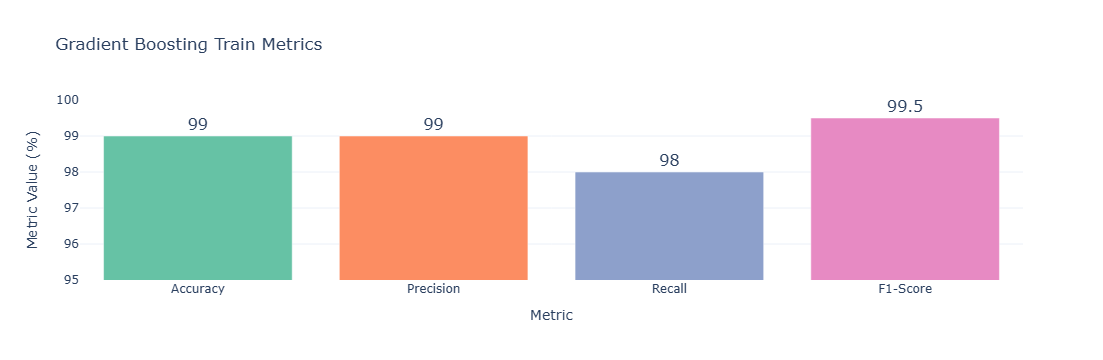

In [84]:
import pandas as pd
import plotly.express as px

# Example data for metrics
metrics_data = {
    "Model": ["Gradient Boosting"] * 4,  # Repeat "Random Forest" to match the length of the other lists
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [99,99,98,99.5],
}

df = pd.DataFrame(metrics_data)

# Create a plot for the model
fig = px.bar(
    df,
    x="Metric",
    y="Value",
    color="Metric",
    title="Gradient Boosting Train Metrics",
    labels={"Value": "Metric Value (%)", "Metric": "Metric"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    text="Value",
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="outside"  # Place the text outside the bars for better visibility
)

fig.update_layout(
    yaxis=dict(title="Metric Value (%)", range=[95, 100]),
    template="plotly_white",
    showlegend=False
)

fig.show()


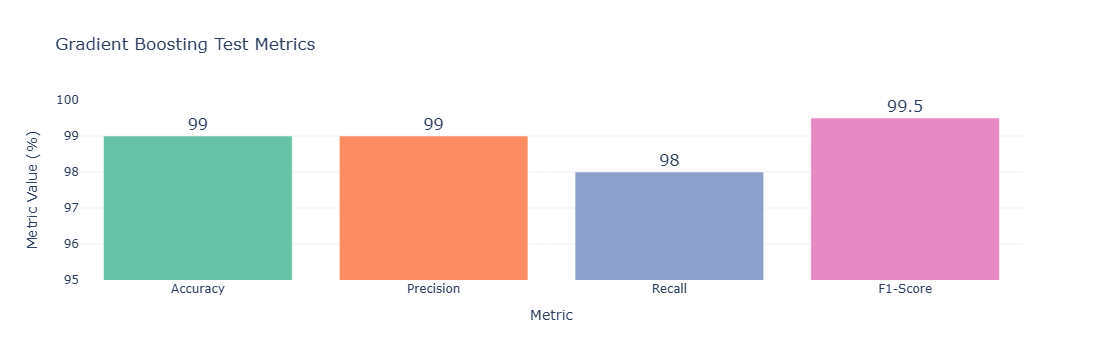

In [85]:
import pandas as pd
import plotly.express as px

# Example data for metrics
metrics_data = {
    "Model": ["Gradient Boosting"] * 4,  # Repeat "Random Forest" to match the length of the other lists
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [99,99,98,99.5],
}

df = pd.DataFrame(metrics_data)

# Create a plot for the model
fig = px.bar(
    df,
    x="Metric",
    y="Value",
    color="Metric",
    title="Gradient Boosting Test Metrics",
    labels={"Value": "Metric Value (%)", "Metric": "Metric"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    text="Value",
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="outside"  # Place the text outside the bars for better visibility
)

fig.update_layout(
    yaxis=dict(title="Metric Value (%)", range=[95, 100]),
    template="plotly_white",
    showlegend=False
)

fig.show()


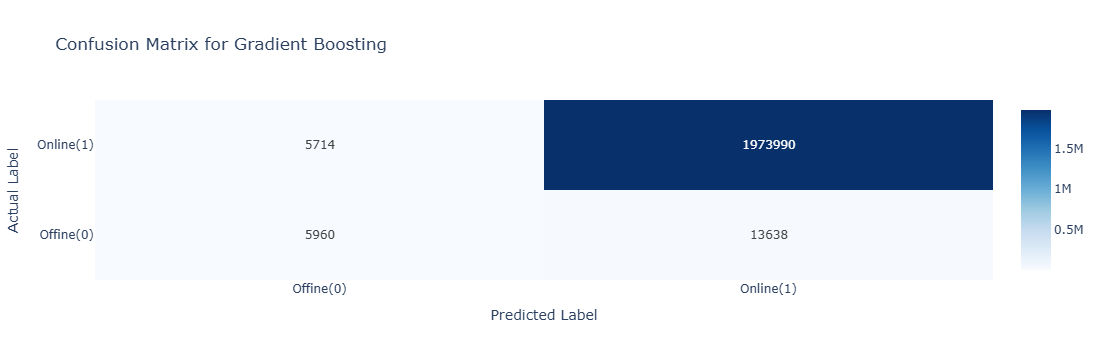

In [148]:
import plotly.graph_objects as go
import pandas as pd
confusion_matrix = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Offine(0)", "Online(1)"],
    columns=["Offine(0)", "Online(1)"]
)

# Extract values for the heatmap
z = confusion_matrix.values
x = confusion_matrix.columns.tolist()  # Predicted labels
y = confusion_matrix.index.tolist()    # Actual labels

# Create a Plotly heatmap
fig = go.Figure(
    data=go.Heatmap(
        z=z,
        x=x,
        y=y,
        colorscale="Blues",
        showscale=True,
        text=z,
        texttemplate="%{text}",
        zmin=0
    )
)

# Add titles and labels
fig.update_layout(
    title="Confusion Matrix for Gradient Boosting",
    xaxis_title="Predicted Label",
    yaxis_title="Actual Label",
    xaxis=dict(tickmode="array", tickvals=[0, 1], ticktext=x),
    yaxis=dict(tickmode="array", tickvals=[0, 1], ticktext=y),
    template="plotly_white"
)

# Show the interactive plot
fig.show()

In [88]:
importances = model.featureImportances

In [89]:
# Get feature names from the VectorAssembler input columns
feature_names = Cols  # This is the list of feature column names you used in VectorAssembler

# Combine feature names with their importance scores
feature_importance = [(name, importance) for name, importance in zip(feature_names, importances)]

In [90]:
# Sort features by importance and display
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

for feature, importance in feature_importance:
    print(f"Feature: {feature}, Importance: {importance:.4f}")

Feature: IS_AUTH, Importance: 0.9868
Feature: NS_SEEN, Importance: 0.0076
Feature: SERIAL, Importance: 0.0056


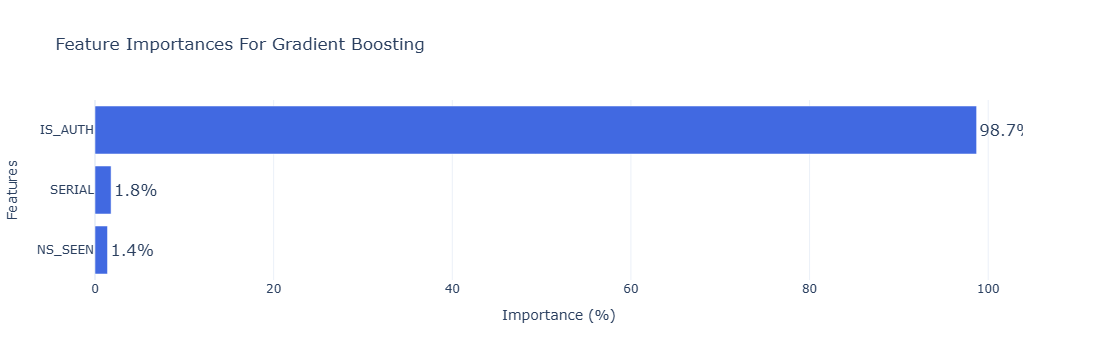

In [18]:
import plotly.graph_objects as go

# Example feature importance data
feature_importance = [
    ("IS_AUTH", 0.9868),
    ("SERIAL",0.0184),
    ("NS_SEEN", 0.0144)
]

# Extract features and their importances, converting to percentages with 1 decimal point
features = [feature for feature, importance in feature_importance]
importances = [round(importance * 100, 1) for feature, importance in feature_importance]

# Create the Plotly horizontal bar chart
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=importances,
        y=features,
        orientation='h',  # Horizontal bar chart
        marker=dict(color='royalblue'),  # Customize bar color
        text=importances,  # Show importance as text on the bars
        texttemplate="%{text}%",  # Append percentage sign to the text
        textposition="auto"
    )
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="outside"  # Place the text outside the bars for better visibility
)
# Customize layout
fig.update_layout(
    title="Feature Importances For Gradient Boosting",
    xaxis_title="Importance (%)",
    yaxis_title="Features",
    yaxis=dict(autorange="reversed"),  # Reverse y-axis for readability
    template="plotly_white"
)

# Show the plot
fig.show()


In [155]:
layers = [2, 10,5, 2]  # Input layer, two hidden layers, output layer

mlp = MultilayerPerceptronClassifier(
    featuresCol="pca_features", 
    labelCol="IS_ONLINE", 
    maxIter=100, 
    layers=layers, 
    blockSize=128, 
    seed=42
)

# Train the MLP model
mlp_model = mlp.fit(train_data)

In [156]:
train_predictions = model.transform(train_data)
test_predictions = model.transform(test_data)


In [157]:
# Initialize BinaryClassificationEvaluator
binary_evaluator = BinaryClassificationEvaluator(
    labelCol="IS_ONLINE", 
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC"  # or "areaUnderPR"
)

# Calculate train metrics
train_auc = binary_evaluator.evaluate(train_predictions)
test_auc = binary_evaluator.evaluate(test_predictions)

# Print results
print(f"Train AUC: {train_auc:.2f}")
print(f"Test AUC: {test_auc:.2f}")


Train AUC: 1.00
Test AUC: 1.00


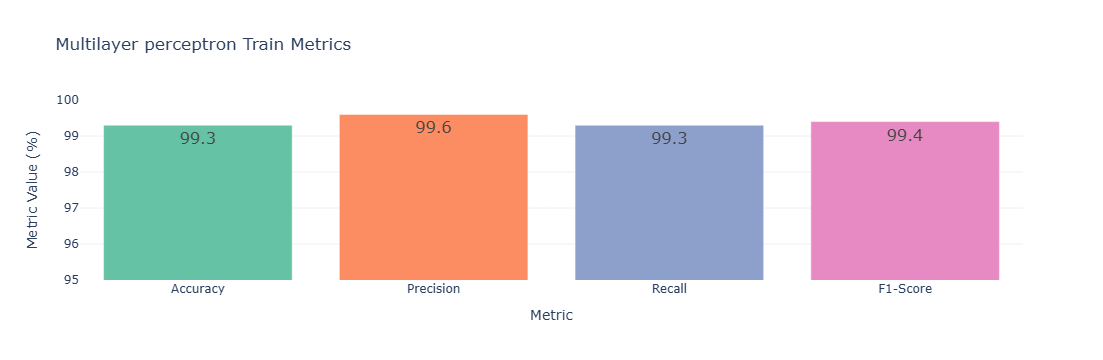

In [158]:
import pandas as pd
import plotly.express as px

# Example data for metrics
metrics_data = {
    "Model": ["Multilayer Perceptron"] * 4,  # Repeat "Random Forest" to match the length of the other lists
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [99.3,99.6,99.3,99.4],
}

df = pd.DataFrame(metrics_data)

# Create a plot for the model
fig = px.bar(
    df,
    x="Metric",
    y="Value",
    color="Metric",
    title="Multilayer perceptron Train Metrics",
    labels={"Value": "Metric Value (%)", "Metric": "Metric"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    text="Value",
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="inside"  # Place the text outside the bars for better visibility
)

fig.update_layout(
    yaxis=dict(title="Metric Value (%)", range=[95, 100]),
    template="plotly_white",
    showlegend=False
)

fig.show()


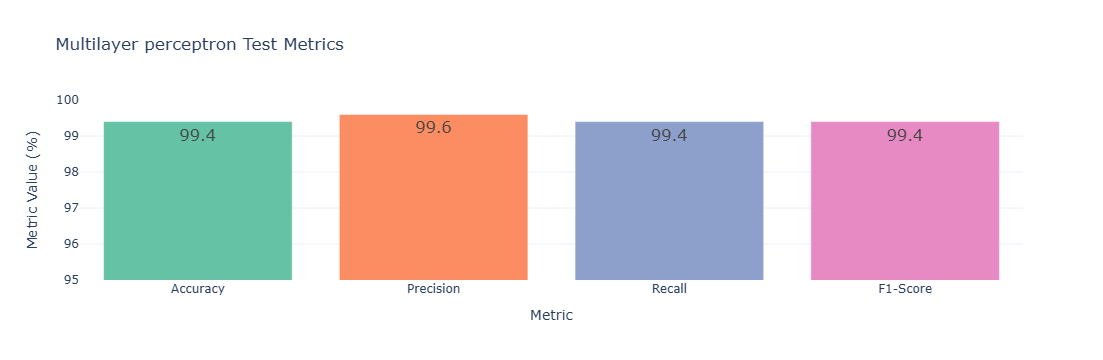

In [159]:
import pandas as pd
import plotly.express as px

# Example data for metrics
metrics_data = {
    "Model": ["Multilayer Perceptron"] * 4,  # Repeat "Random Forest" to match the length of the other lists
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [99.4,99.6,99.4,99.4],
}

df = pd.DataFrame(metrics_data)

# Create a plot for the model
fig = px.bar(
    df,
    x="Metric",
    y="Value",
    color="Metric",
    title="Multilayer perceptron Test Metrics",
    labels={"Value": "Metric Value (%)", "Metric": "Metric"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    text="Value",
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="inside"  # Place the text outside the bars for better visibility
)

fig.update_layout(
    yaxis=dict(title="Metric Value (%)", range=[95, 100]),
    template="plotly_white",
    showlegend=False
)

fig.show()

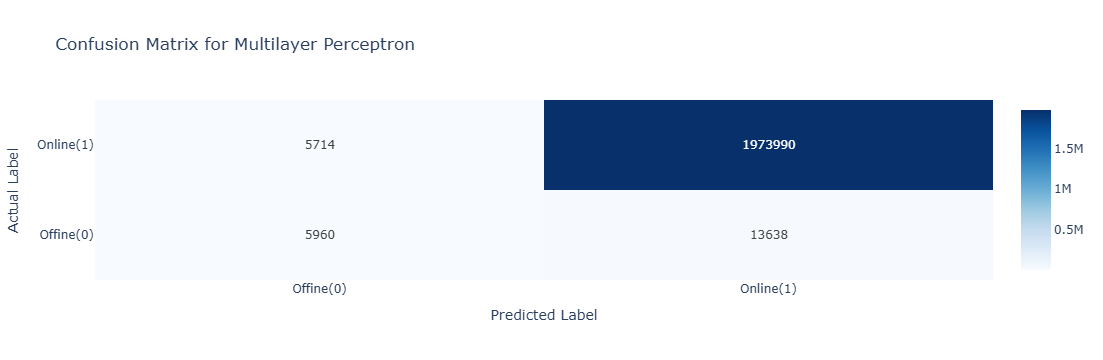

In [160]:
confusion_matrix = test_predictions.groupBy("IS_ONLINE", "prediction").count().orderBy("IS_ONLINE", "prediction")
confusion_matrix = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Offine(0)", "Online(1)"],
    columns=["Offine(0)", "Online(1)"]
)

# Extract values for the heatmap
z = confusion_matrix.values
x = confusion_matrix.columns.tolist()  # Predicted labels
y = confusion_matrix.index.tolist()    # Actual labels

# Create a Plotly heatmap
fig = go.Figure(
    data=go.Heatmap(
        z=z,
        x=x,
        y=y,
        colorscale="Blues",
        showscale=True,
        text=z,
        texttemplate="%{text}",
        zmin=0
    )
)

# Add titles and labels
fig.update_layout(
    title="Confusion Matrix for Multilayer Perceptron",
    xaxis_title="Predicted Label",
    yaxis_title="Actual Label",
    xaxis=dict(tickmode="array", tickvals=[0, 1], ticktext=x),
    yaxis=dict(tickmode="array", tickvals=[0, 1], ticktext=y),
    template="plotly_white"
)

# Show the interactive plot
fig.show()

In [180]:
logistic_regression = LogisticRegression(featuresCol="pca_features", labelCol="IS_ONLINE")

In [181]:
lr = logistic_regression.fit(train_data)

In [182]:
predictions = lr.transform(test_data)

In [183]:
train_predictions = lr.transform(train_data)

# Initialize evaluators for binary and multiclass metrics
binary_evaluator = BinaryClassificationEvaluator(labelCol="IS_ONLINE", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
multi_evaluator = MulticlassClassificationEvaluator(labelCol="IS_ONLINE", predictionCol="prediction")

# Calculate metrics on the training set
train_auc = binary_evaluator.evaluate(train_predictions)  # Area Under ROC
train_accuracy = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "accuracy"})
train_precision = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "weightedPrecision"})
train_recall = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "weightedRecall"})
train_f1_score = multi_evaluator.evaluate(train_predictions, {multi_evaluator.metricName: "f1"})

# Print training set metrics
print("Training Set Metrics:")
print(f"AUC: {train_auc}")
print(f"Accuracy: {train_accuracy}")
print(f"Precision: {train_precision}")
print(f"Recall: {train_recall}")
print(f"F1 Score: {train_f1_score}")

Training Set Metrics:
AUC: 0.9955774408773569
Accuracy: 0.9934613204997864
Precision: 0.996089431991951
Recall: 0.9934613204997864
F1 Score: 0.9942727694390991


In [184]:
from pyspark.sql import functions as F
tp = predictions.filter((F.col("IS_ONLINE") == 1) & (F.col("prediction") == 1)).count()
tn = predictions.filter((F.col("IS_ONLINE") == 0) & (F.col("prediction") == 0)).count()
fp = predictions.filter((F.col("IS_ONLINE") == 0) & (F.col("prediction") == 1)).count()
fn = predictions.filter((F.col("IS_ONLINE") == 1) & (F.col("prediction") == 0)).count()

# Print TP, TN, FP, FN values
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Calculate evaluation metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Testset Set Metrics:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")

True Positives (TP): 1967058
True Negatives (TN): 19598
False Positives (FP): 0
False Negatives (FN): 12646
Testset Set Metrics:
Accuracy: 0.9936747925025834
Precision: 1.0
Recall: 0.9936121763657597
F1 Score: 0.9967958544244624


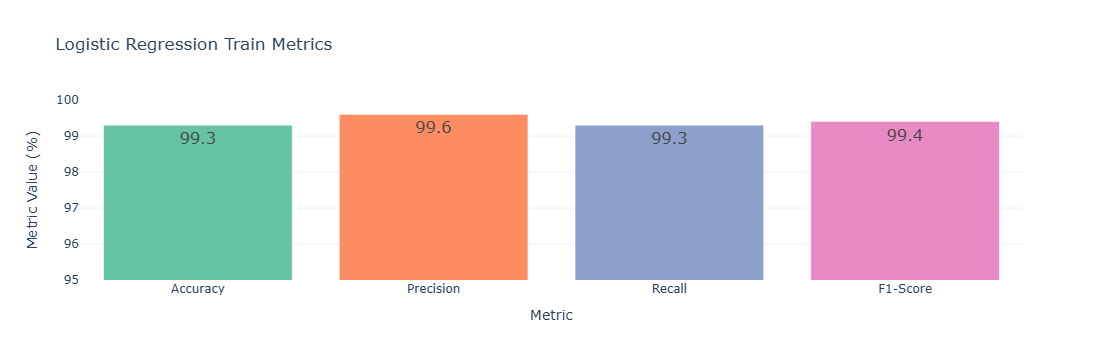

In [185]:
import pandas as pd
import plotly.express as px

# Example data for metrics
metrics_data = {
    "Model": ["Multilayer Perceptron"] * 4,  # Repeat "Random Forest" to match the length of the other lists
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [99.3,99.6,99.3,99.4],
}

df = pd.DataFrame(metrics_data)

# Create a plot for the model
fig = px.bar(
    df,
    x="Metric",
    y="Value",
    color="Metric",
    title="Logistic Regression Train Metrics",
    labels={"Value": "Metric Value (%)", "Metric": "Metric"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    text="Value",
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="inside"  # Place the text outside the bars for better visibility
)

fig.update_layout(
    yaxis=dict(title="Metric Value (%)", range=[95, 100]),
    template="plotly_white",
    showlegend=False
)

fig.show()

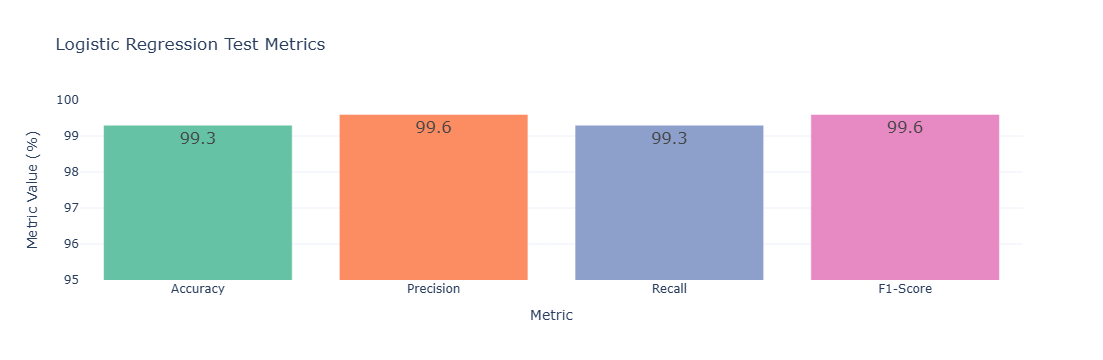

In [186]:
import pandas as pd
import plotly.express as px

# Example data for metrics
metrics_data = {
    "Model": ["Multilayer Perceptron"] * 4,  # Repeat "Random Forest" to match the length of the other lists
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [99.3,99.6,99.3,99.6],
}

df = pd.DataFrame(metrics_data)

# Create a plot for the model
fig = px.bar(
    df,
    x="Metric",
    y="Value",
    color="Metric",
    title="Logistic Regression Test Metrics",
    labels={"Value": "Metric Value (%)", "Metric": "Metric"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    text="Value",
)
fig.update_traces(
    textfont_size=16,  # Increase text size
    textposition="inside"  # Place the text outside the bars for better visibility
)

fig.update_layout(
    yaxis=dict(title="Metric Value (%)", range=[95, 100]),
    template="plotly_white",
    showlegend=False
)

fig.show()

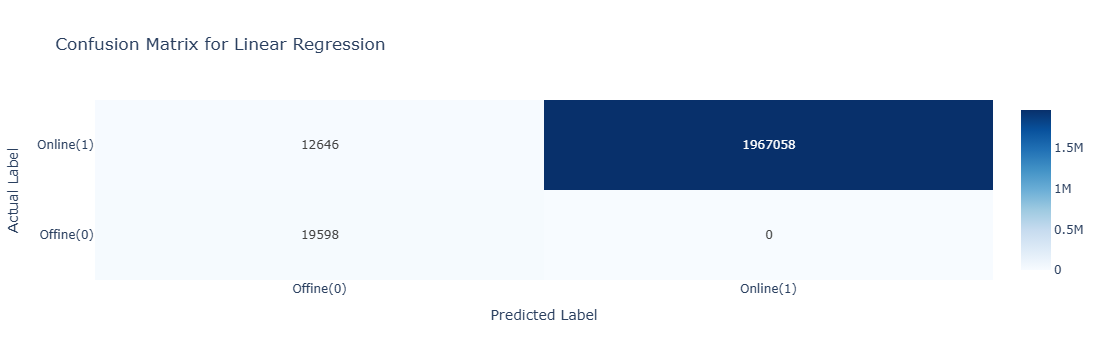

In [187]:
import plotly.graph_objects as go
import pandas as pd
confusion_matrix = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Offine(0)", "Online(1)"],
    columns=["Offine(0)", "Online(1)"]
)

# Extract values for the heatmap
z = confusion_matrix.values
x = confusion_matrix.columns.tolist()  # Predicted labels
y = confusion_matrix.index.tolist()    # Actual labels

# Create a Plotly heatmap
fig = go.Figure(
    data=go.Heatmap(
        z=z,
        x=x,
        y=y,
        colorscale="Blues",
        showscale=True,
        text=z,
        texttemplate="%{text}",
        zmin=0
    )
)

# Add titles and labels
fig.update_layout(
    title="Confusion Matrix for Linear Regression",
    xaxis_title="Predicted Label",
    yaxis_title="Actual Label",
    xaxis=dict(tickmode="array", tickvals=[0, 1], ticktext=x),
    yaxis=dict(tickmode="array", tickvals=[0, 1], ticktext=y),
    template="plotly_white"
)

# Show the interactive plot
fig.show()

In [188]:
coefficients = lr.coefficients
intercept = lr.intercept


importance = list(zip(Cols, coefficients))

# Sort by importance
sorted_importance = sorted(importance, key=lambda x: abs(x[1]), reverse=True)

# Print feature importances
print("Feature Importances for Logistic Regression:")
for feature, coef in sorted_importance:
    print(f"{feature}: {coef:.4f}")

Feature Importances for Logistic Regression:
IS_AUTH: -81.7833
SERIAL: -0.0082
NS_SEEN: 0.0040


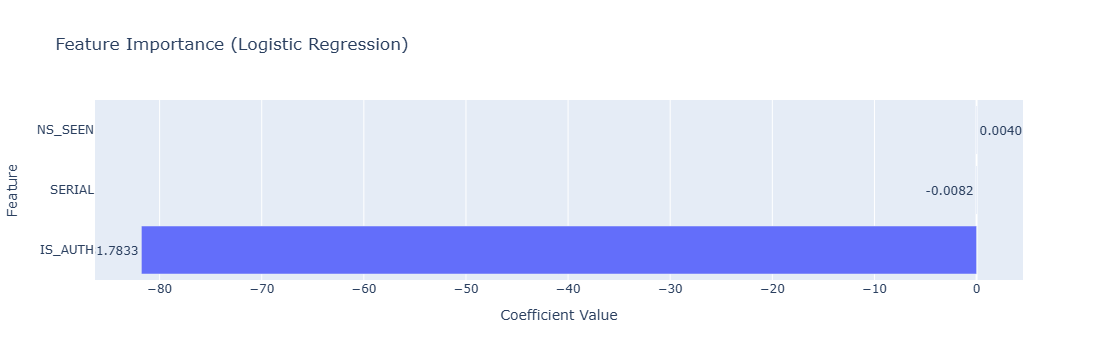

In [189]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for visualization
importance_df = pd.DataFrame(sorted_importance, columns=["Feature", "Coefficient"])

# Plot feature importance
fig = px.bar(
    importance_df, 
    y="Feature", 
    x="Coefficient", 
    title="Feature Importance (Logistic Regression)",
    labels={"Coefficient": "Coefficient Value"},
    text="Coefficient"
)
fig.update_traces(texttemplate='%{text:.4f}', textposition="outside")
fig.show()